# Decision summary: real-only baselines on two spectral axes

The most informative metrics of reconstruction, latent geometry and prediction are collected per axis in one table, as the reference against which pretrained models will be compared.

## Introduction

Every value is a model-level quantity per repetition; the table gives mean and SD over the five repetitions.
Metric definitions are those of the notebooks cited in the metric families.

### Assumptions

* `test` pixels come from training images and are spatially correlated with training pixels; `heldout_image`
  pixels come from three images never seen during training. Generalization to new images is therefore judged on
  `heldout_image`, generalization to new pixels on `test`.
* Repetitions differ only in initialization and training seed; they share the split. Five repetitions per axis
  are the experimental units for model-level statements; pixels are not independent units.

* Both axes are evaluated on identical pixels (same source spectra), so per-pixel comparisons are paired. The
  models of the two axes are independent; repetition $r$ of one axis is paired with repetition $r$ of the other only
  for convenience (the seeds are equal but the models are not related).
* Global $W_1$ values are not comparable across axes: the wide axis transports intensity over a longer m/z range and
  normalizes by a TIC that includes the extension. Comparisons of reconstruction therefore use the windows shared by
  both axes, where the within-window cost is renormalized and comparable.

### Notation

* $X \in \mathbb{R}_{\ge 0}^{M}$: TIC-normalized input spectrum on the axis ($M$ bins of 0.55 Da);
  $\hat X = \mathrm{Dec}(\mathrm{Enc}(X))$: its reconstruction (TIC-normalized decoder output).
* $Z = \mathrm{Enc}(X) \in \mathbb{R}^{10}$: latent code; $U$: canonicalized code (bottleneck LayerNorm affine
  removed; rows lie on a sphere of radius $\sqrt{10}$ with zero row sum).
* $\hat Y = \sigma(h(Z)) \in [0, 1]^{C}$: head probabilities of the $C$ train-observed molecule classes.
* $P \in \{\mathrm{train}, \mathrm{test}, \mathrm{test\_extended}, \mathrm{heldout\_image}\}$: pixel population;
  $r = 0, \dots, 4$: repetition (independent training seed of the same configuration).
* $W_1(X, \hat X)$: training Masserstein cost, the exact one-dimensional Wasserstein-1 distance between the
  TIC-normalized spectra, in m/z units.
* Window $W = [a, a + 100)$ m/z, aligned to multiples of 100 on every axis.

* Narrow axis $\mathcal{A}_n$ = 200-900 m/z (1273 bins); wide axis $\mathcal{A}_w$ = 100-3000 m/z (5273 bins); common
  windows = 200-300, ..., 800-900; extension windows = 100-200 and 900-3000.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "decision_summary"
AXIS = None

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(catalog.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

POPULATIONS = ['train', 'test', 'test_extended', 'heldout_image']
NARROW, WIDE = metadata.get('narrow_axis', 'axis-200-900'), metadata.get('wide_axis', 'axis-100-3000')
AXIS_LABELS = {axis: catalog[catalog.axis == axis].display_label.iloc[0] for axis in (NARROW, WIDE)}
AXIS_COLORS = {axis: LABEL_COLORS[AXIS_LABELS[axis]] for axis in (NARROW, WIDE)}
DATASETS = sorted(load_table(settings, 'axis_comparison_reconstruction', 'image_maps').dataset_id.unique())
print('Narrow axis:', NARROW, '| wide axis:', WIDE, '| held-out images:', DATASETS)

metrics = table('decision_metrics')
decision_table = table('decision_table')

Analysis: decision_summary | axis: None | models: 10
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'inference': '0243c1efb93b9c4c'}
Narrow axis: axis-200-900 | wide axis: axis-100-3000 | held-out images: ['2024-02-20_01h45m20s', '2024-02-20_01h46m58s', '2024-02-20_01h54m41s']


## Producing the tables this notebook reads

### Methodology

#### Implementation

`decision_summary` recomputes the selected metrics from the shared cache with the functions of the individual notebooks.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis decision_summary > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Decision table

### Methodology

#### Theoretical

Mean and SD over repetitions per axis, metric family, metric and population.

#### Implementation

`decision_table`.

#### Figure descriptions

No figure.

In [3]:
display(decision_table.pivot_table(index=['family', 'metric', 'population'], columns='axis', values=['mean', 'std']).round(4))

mean                        std             
axis                                                                      axis-100-3000 axis-200-900 axis-100-3000 axis-200-900
family         metric                                       population                                                         
latent         cos_theta_sd_over_uniform                    heldout_image        1.0642       1.1026        0.1131       0.0590
                                                            test                 1.0310       1.0623        0.0379       0.0420
               effective_rank                               heldout_image        1.8889       2.0125        0.1331       0.0629
                                                            test                 5.0968       4.5986        0.1636       0.1497
               participation_ratio                          heldout_image        1.3605       1.4072        0.0661       0.0327
                                                            test                 3.9120       3.3982        0.1406       0.1517
               sensitivity_angle_at_0.01                    heldout_image        0.1829       0.3149        0.0328       0.0136
                                                            test                 0.2575       0.2566        0.0279       0.0096
               two_nn_intrinsic_dimension                   heldout_image        5.5844       5.6523        0.1115       0.0580
                                                            test                 5.2477       5.3278        0.1088       0.0805
prediction     annotation_retrieval_average_precision       heldout_image        0.3761       0.3557        0.0164       0.0075
                                                            test_combined        0.7084       0.7088        0.0079       0.0033
               annotation_retrieval_micro_average_precision heldout_image        0.5809       0.5924        0.0191       0.0097
                                                            test_combined        0.8696       0.8828        0.0066       0.0088
               macro_ap_common_classes                      test_combined        0.7048       0.7088        0.0074       0.0033
               macro_ap_extension_classes                   test_combined        0.7411          NaN        0.0124          NaN
               metaspace_spearman_median                    heldout_image        0.3335       0.2745        0.0248       0.0450
               operational_pn_average_precision             heldout_image        0.8037       0.7688        0.0071       0.0030
                                                            test_combined        0.8488       0.8786        0.0061       0.0022
               operational_pn_micro_average_precision       heldout_image        0.9281       0.9233        0.0072       0.0010
                                                            test_combined        0.9048       0.9796        0.0054       0.0041
reconstruction common_window_within_mean                    heldout_image        6.4683       5.2220        1.1801       0.1303
                                                            test                 5.4603       4.7466        0.4886       0.1863
                                                            test_extended        6.3501       5.7934        0.3406       0.1379
                                                            train                5.4237       4.7320        0.4770       0.1913
               extension_emptied_fraction                   heldout_image        0.0000          NaN        0.0001          NaN
                                                            test                 0.0075          NaN        0.0113          NaN
                                                            test_extended        0.0147          NaN        0.0168          NaN
                                                            train                0.0073          NaN        0.0111 

### Remarks

### Notes

## Repetition-level view of the key metrics

### Methodology

#### Theoretical

The repetition points show whether an axis difference is larger than the spread between repetitions.

#### Implementation

`decision_metrics`; one panel per metric and population.

#### Figure descriptions

x = axis, one point per repetition, bar = mean; panels = metrics.

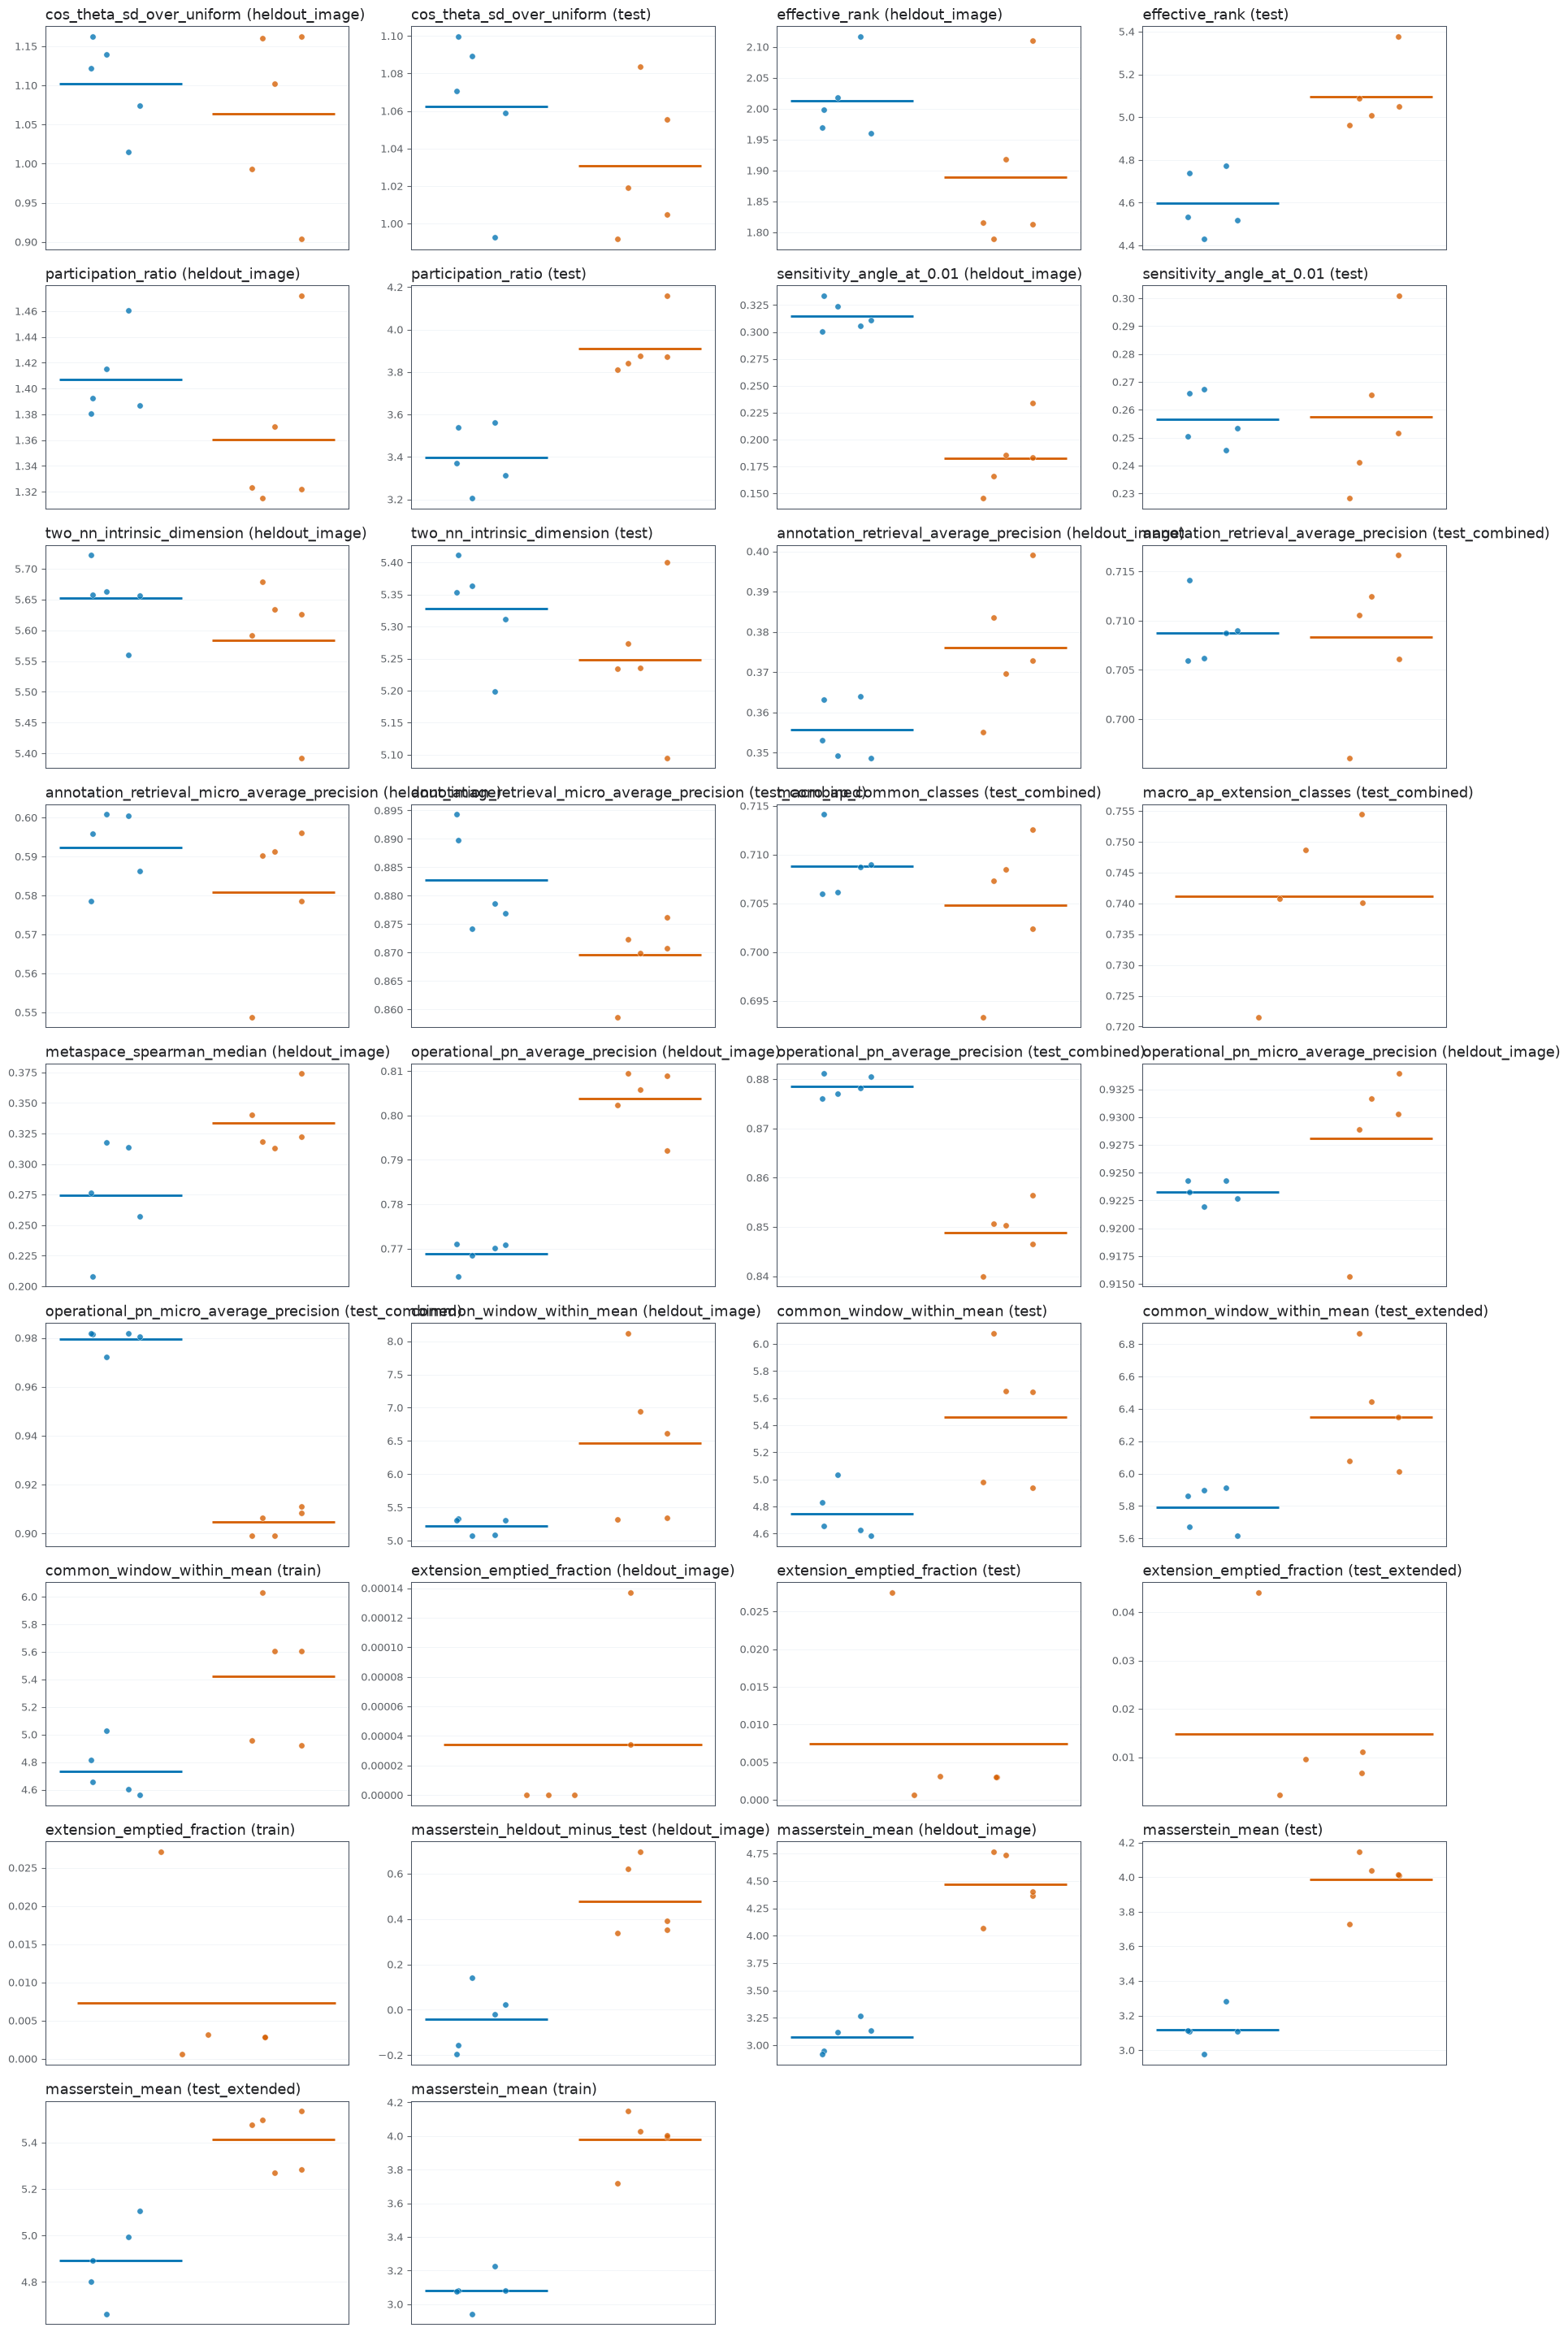

In [4]:
keys = metrics[['family', 'metric', 'population']].drop_duplicates().sort_values(['family', 'metric', 'population'])
figure, axes = plt.subplots(int(np.ceil(len(keys) / 4)), 4, figsize=(18, 3.2 * int(np.ceil(len(keys) / 4))), dpi=theme.figure_dpi, squeeze=False)
for ax, key in zip(axes.flat, keys.itertuples()):
    frame = metrics[(metrics.metric == key.metric) & (metrics.population == key.population)].assign(group='axis')
    figures.repetition_points(frame, value='value', group='group', hue='axis', order=['axis'], hue_order=[NARROW, WIDE], colors=AXIS_COLORS, ylabel='', title=f'{key.metric} ({key.population})', ax=ax, theme=theme)
    ax.set_xticks([])
    ax.get_legend().remove() if ax.get_legend() else None
for ax in axes.flat[len(keys):]:
    ax.set_visible(False)
figure.tight_layout()

### Remarks

### Notes

## Results / Summary

### LLM

**Reference for the pretraining comparisons (real-only baselines, five repetitions per axis):**

- **Data contract:** verified against the original split and all saved models; recorded validation/test losses are sampler-biased (plain test W1 3-8 % lower).
- **Reconstruction:** generalizes to new pixels and, on the 200-900 axis, to new images (W1 3.12 test vs 3.08 held-out); on the 100-3000 axis the held-out W1 rises by 0.48 because of a different m/z composition of the held-out images, not a local failure. Local errors concentrate in low-mass windows (500-700 m/z), at tissue borders and in low-intensity pixels.
- **Wide axis cost:** the within-window cost in the peak-rich common windows is higher for 80-90 % of pixels and peaks are reconstructed at about half their height; the extension is reconstructed (masses reproduced, no emptied windows) but its ions are flattened (22-42 % intensity).
- **Latent:** not saturated on either axis (TwoNN about 5 of 8); highly reproducible (CKA >= 0.96); held-out codes are shifted by about 0.6-0.7 training SD per dimension.
- **Prediction:** no generalization gap to new pixels (macro AP about 0.70); a large gap to new images (macro AP about 0.37, ROC AUC about 0.71, recall at 0.5 below 0.31) on both axes; extension classes are learned as well as common ones.
- **Decision:** the wide axis is a viable basis (no loss on common molecules, 55 additional classes, slightly better on new images) at a measurable reconstruction cost. The main open problem is the head's image-level generalization; pretraining should be judged primarily on held-out-image prediction (recall/ROC AUC, METASPACE agreement) and on the common-window reconstruction cost of the wide axis.
- **Caveats:** three held-out images with 9-14 annotations each; BIC-selected segmentations at k = 12 are not reproducible; training stopped slightly before convergence.
- **Peak shape (second round):** zoomed spectra show that both decoders produce envelopes instead of peaks (apex about 44 % of the input on 200-900, about 15 % on 100-3000; position error 3 bins); single m/z channel images of weak peaks lose their spatial pattern (median channel r 0.36-0.48), while 100 Da window masses are reproduced pixel by pixel.
- **Evaluation of new images (second round):** per-image metrics (macro AP 0.52-0.66) are the fair measure; pooled held-out metrics are depressed by annotations missing across images. On new images the ranking transfers but probabilities shift below 0.5 (micro recall 0.21-0.36, precision about 0.9).
- **Target definition:** the `METASPACE intensity > 0` target makes the head predict presence of any signal, not where an ion is strong; spatial agreement with METASPACE intensity is not a training objective.
- **Segmentation:** five to six reproducible latent regions on new images on both axes (k = 6: ARI 0.97 across axes); finer segmentations are model-specific.

### Person